In [ ]:
# @title Import
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

print("Library imports done.")

Library imports done.


In [ ]:
# @title Data Exploration & Loading
from google.colab import files

uploaded = files.upload()

X = np.load('/content/water_stress_tensors_generate.npy')
y = np.load('/content/water_stress_labels_generate.npy').astype(np.float32)

print(f"  X shape : {X.shape}  →  (samples, timesteps, H, W, features)")
print(f"  y shape : {y.shape}")
print(f"  Stressed: {y.sum():.0f}  |  Not-Stressed: {(1-y).sum():.0f}")

Saving water_stress_tensors_generate.npy to water_stress_tensors_generate (2).npy
Saving water_stress_metadata_generate.csv to water_stress_metadata_generate (2).csv
Saving water_stress_labels_generate.npy to water_stress_labels_generate (2).npy
  X shape : (1000, 5, 4, 4, 7)  →  (samples, timesteps, H, W, features)
  y shape : (1000,)
  Stressed: 500  |  Not-Stressed: 500


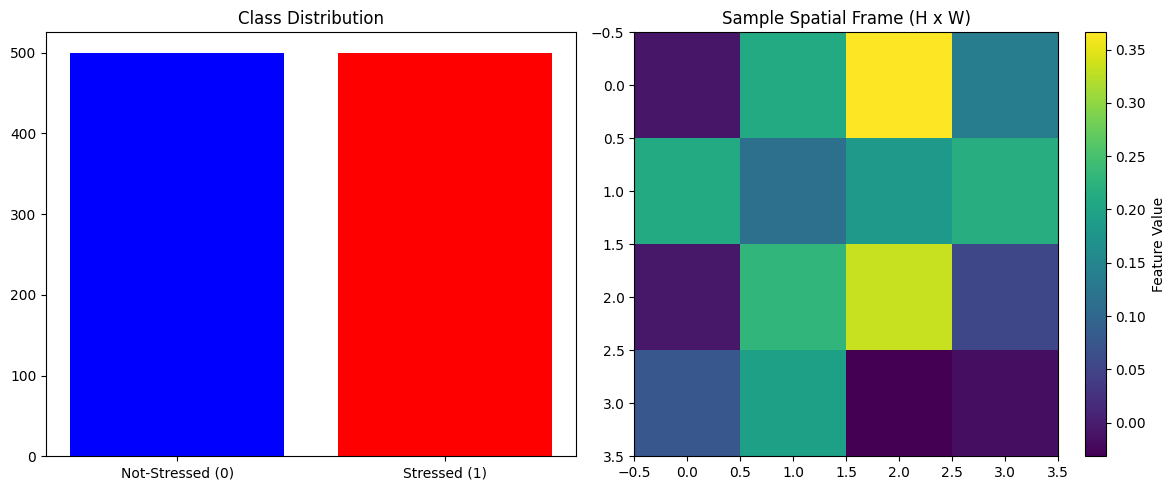

In [ ]:
# @title Data Visualization & Class Balance Check
import matplotlib.pyplot as plt
import numpy as np

def plot_data_info(X, y):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    unique, counts = np.unique(y, return_counts=True)
    plt.bar(['Not-Stressed (0)', 'Stressed (1)'], counts, color=['blue', 'red'])
    plt.title('Class Distribution')

    plt.subplot(1, 2, 2)
    sample_frame = X[0, 0, :, :, 0]
    plt.imshow(sample_frame, cmap='viridis')
    plt.colorbar(label='Feature Value')
    plt.title('Sample Spatial Frame (H x W)')

    plt.tight_layout()
    plt.show()

plot_data_info(X, y)

In [ ]:
# @title Dataset Splitting & Loading
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=150, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=150, random_state=42, stratify=y_train_val
)

train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))
test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train size: {len(X_train)}")
print(f"Val size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

Train size: 700
Val size: 150
Test size: 150


In [ ]:
# @title CNN + Transformer Model Architecture
import torch
import torch.nn as nn

class CNNTransformer(nn.Module):
    def __init__(self):
        super(CNNTransformer, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(7, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )

        self.feature_dim = 8 * 4 * 4

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.feature_dim,
            nhead=4,
            dim_feedforward=128,
            dropout=0.5,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)

        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch_size, timesteps, h, w, features = x.shape
        x = x.view(batch_size * timesteps, h, w, features).permute(0, 3, 1, 2)

        cnn_out = self.cnn(x)
        cnn_out = cnn_out.view(batch_size, timesteps, -1)

        trans_out = self.transformer(cnn_out)
        out = self.classifier(trans_out[:, -1, :])
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNNTransformer().to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Device: {device}")
print(f"New Total Parameters: {total_params:,}")

Device: cpu
New Total Parameters: 105,929


In [ ]:
# @title Model Training Pipeline: Loss Optimization and Model Checkpointing
import torch.optim as optim

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

EPOCHS = 50
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
patience_counter = 0
patience_limit = 7

print(f"Starting Optimized Training...\n")

for epoch in range(1, EPOCHS + 1):
    model.train()
    t_loss, t_correct, t_total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device).unsqueeze(1)
        optimizer.zero_grad()
        logit = model(xb)
        loss = criterion(logit, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        t_loss += loss.item() * len(yb)
        preds = (logit > 0.5).float()
        t_correct += (preds == yb).sum().item()
        t_total += len(yb)

    model.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device).unsqueeze(1)
            logit = model(xb)
            loss = criterion(logit, yb)
            v_loss += loss.item() * len(yb)
            preds = (logit > 0.5).float()
            v_correct += (preds == yb).sum().item()
            v_total += len(yb)

    t_loss /= t_total; v_loss /= v_total
    t_acc = t_correct / t_total; v_acc = v_correct / v_total
    scheduler.step(v_loss)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_optimized_model.pth')
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train Loss: {t_loss:.4f} Acc: {t_acc:.3f} | Val Loss: {v_loss:.4f} Acc: {v_acc:.3f}")

    if patience_counter >= patience_limit:
        print(f"\n[Early Stopping] Triggered at epoch {epoch}. Best Val Loss: {best_val_loss:.4f}")
        break

print("\nOptimized Training Complete!")

Starting Optimized Training...

Epoch   1 | Train Loss: 0.7057 Acc: 0.527 | Val Loss: 0.6812 Acc: 0.533
Epoch   5 | Train Loss: 0.6452 Acc: 0.617 | Val Loss: 0.6068 Acc: 0.673
Epoch  10 | Train Loss: 0.5785 Acc: 0.726 | Val Loss: 0.5201 Acc: 0.747
Epoch  15 | Train Loss: 0.4638 Acc: 0.801 | Val Loss: 0.3778 Acc: 0.853
Epoch  20 | Train Loss: 0.3779 Acc: 0.844 | Val Loss: 0.3754 Acc: 0.820
Epoch  25 | Train Loss: 0.2961 Acc: 0.894 | Val Loss: 0.3218 Acc: 0.867
Epoch  30 | Train Loss: 0.3069 Acc: 0.884 | Val Loss: 0.2909 Acc: 0.867
Epoch  35 | Train Loss: 0.2698 Acc: 0.906 | Val Loss: 0.3092 Acc: 0.867

[Early Stopping] Triggered at epoch 37. Best Val Loss: 0.2909

Optimized Training Complete!


In [ ]:
# @title Training Results Summary
import pandas as pd

final_epoch = len(history['train_loss'])
report_data = {
    'Metric': ['Loss (Lower is better)', 'Accuracy (Higher is better)'],
    'Initial (Epoch 1)': [
        f"{history['train_loss'][0]:.4f}",
        f"{history['train_acc'][0]*100:.2f}%"
    ],
    'Final (Epoch 40)': [
        f"{history['train_loss'][-1]:.4f}",
        f"{history['train_acc'][-1]*100:.2f}%"
    ],
    'Val (Best)': [
        f"{min(history['val_loss']):.4f}",
        f"{max(history['val_acc'])*100:.2f}%"
    ]
}

report_df = pd.DataFrame(report_data)

print("--- Training Progress Report ---")
print(report_df.to_string(index=False))

gap = (history['train_acc'][-1] - history['val_acc'][-1]) * 100
print(f"\n ---Analysis--- ")
print(f"Overfitting Gap: {gap:.2f}%")
if gap > 15:
    print("Insight: High overfitting detected. Model is memorizing training data.")
else:
    print("Insight: Generalization looks reasonable.")

--- Training Progress Report ---
                     Metric Initial (Epoch 1) Final (Epoch 40) Val (Best)
     Loss (Lower is better)            0.7057           0.2658     0.2909
Accuracy (Higher is better)            52.71%           89.86%     88.00%

 ---Analysis--- 
Overfitting Gap: 2.52%
Insight: Generalization looks reasonable.


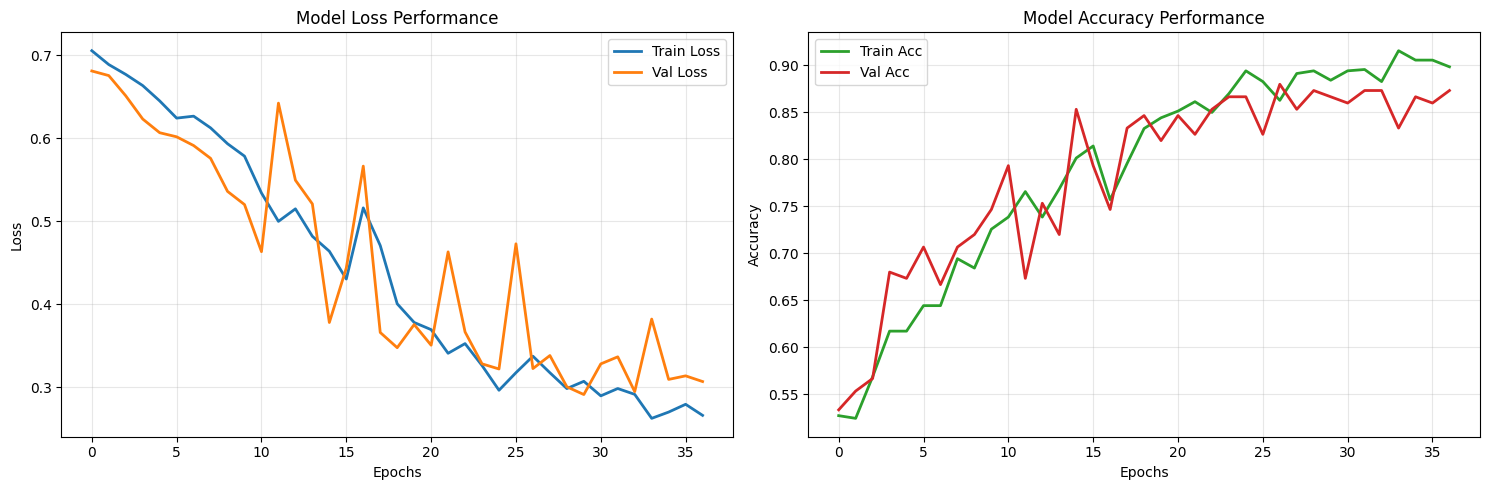

In [ ]:
# @title Performance Evaluation: Loss & Accuracy Trends
import matplotlib.pyplot as plt

def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history['train_loss'], label='Train Loss', color='#1f77b4', lw=2)
    ax1.plot(history['val_loss'], label='Val Loss', color='#ff7f0e', lw=2)
    ax1.set_title('Model Loss Performance')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history['train_acc'], label='Train Acc', color='#2ca02c', lw=2)
    ax2.plot(history['val_acc'], label='Val Acc', color='#d62728', lw=2)
    ax2.set_title('Model Accuracy Performance')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history)

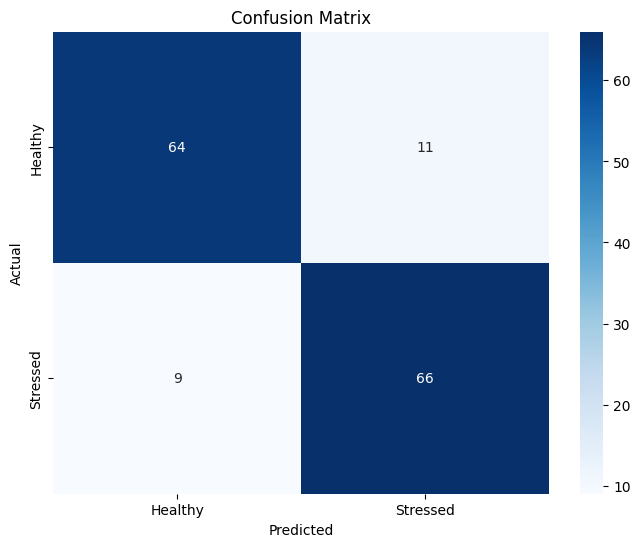


Final Classification Report:
              precision    recall  f1-score   support

     Healthy       0.88      0.85      0.86        75
    Stressed       0.86      0.88      0.87        75

    accuracy                           0.87       150
   macro avg       0.87      0.87      0.87       150
weighted avg       0.87      0.87      0.87       150



In [ ]:
# @title Confusion Matrix & Evaluation Report
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

model.load_state_dict(torch.load('best_optimized_model.pth'))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        outputs = model(xb)
        preds = (outputs > 0.5).float()
        y_true.extend(yb.tolist())
        y_pred.extend(preds.cpu().view(-1).tolist())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Stressed'], yticklabels=['Healthy', 'Stressed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nFinal Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Stressed']))

Sample Index: 59
True Label: Healthy
Predicted Label: Healthy (2.00%)


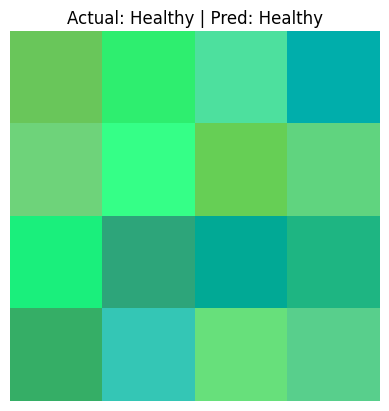

In [ ]:
# @title Model Prediction Preview
import torch
import numpy as np
import matplotlib.pyplot as plt

def predict_random_sample(model, dataset, device):
    model.eval()

    idx = np.random.randint(len(dataset))
    image_seq, label = dataset[idx]

    input_tensor = image_seq.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probability = output.item()
        prediction = 1 if probability > 0.5 else 0

    classes = ['Healthy', 'Stressed']
    print(f"Sample Index: {idx}")
    print(f"True Label: {classes[int(label)]}")
    print(f"Predicted Label: {classes[prediction]} ({probability*100:.2f}%)")

    sample_img = image_seq[-1, :, :, :3].cpu().numpy()

    plt.imshow((sample_img - sample_img.min()) / (sample_img.max() - sample_img.min()))
    plt.title(f"Actual: {classes[int(label)]} | Pred: {classes[prediction]}")
    plt.axis('off')
    plt.show()

predict_random_sample(model, val_dataset, device)